# Notebook 02: Border Detection & Contour Finding

## Goal
Find the outer quadrilateral boundary of the Sudoku grid:
- Adaptive thresholding for binarization
- Contour tracing (Moore-Neighbor algorithm)
- Polygon simplification (Douglas-Peucker)
- Quadrilateral selection and corner ordering

## Why This Matters
Before we can extract the Sudoku grid, we need to find its boundary.
The boundary is a quadrilateral (4-sided polygon) that may be:
- Rotated
- Skewed (perspective distortion)
- Partially occluded

---
## Part A: Theory

### 1. Thresholding

**Global Thresholding:**
$$B(x,y) = \begin{cases} 255 & \text{if } I(x,y) > T \\ 0 & \text{otherwise} \end{cases}$$

Problem: A single threshold fails with varying illumination.

**Adaptive Thresholding:**
Compute a different threshold for each pixel based on its local neighborhood:
$$T(x,y) = \mu_{local}(x,y) - C$$

where $\mu_{local}$ is the mean of pixels in a window around $(x,y)$ and $C$ is a constant.

**Otsu's Method:**
Automatically find the optimal global threshold by maximizing inter-class variance:
$$\sigma_b^2(t) = \omega_0(t) \cdot \omega_1(t) \cdot [\mu_0(t) - \mu_1(t)]^2$$

where $\omega_0, \omega_1$ are class probabilities and $\mu_0, \mu_1$ are class means.

### 2. Moore-Neighbor Contour Tracing

Algorithm to trace the boundary of a connected region:

1. **Start**: Find a boundary pixel (foreground with background neighbor)
2. **Initialize**: Set direction to where we came from
3. **Trace**: 
   - Check neighbors clockwise starting from backtrack direction
   - Move to first foreground pixel found
   - Record the pixel
4. **Stop**: When we return to the start pixel

**Moore Neighborhood** (8-connectivity):
```
  5  6  7
  4  P  0
  3  2  1
```
Directions: 0=E, 1=SE, 2=S, 3=SW, 4=W, 5=NW, 6=N, 7=NE

### 3. Douglas-Peucker Algorithm

Simplifies a curve by reducing the number of points while preserving shape.

**Algorithm:**
1. Connect first and last point with a line
2. Find point with maximum perpendicular distance to this line
3. If max distance > ε (epsilon):
   - Recursively simplify [start, max_point] and [max_point, end]
4. Else: Replace all points with just [start, end]

**Perpendicular Distance:**
For point $P$ and line from $A$ to $B$:
$$d = \frac{|(P-A) \times (B-A)|}{|B-A|}$$

In 2D, the cross product gives:
$$d = \frac{|(P_x - A_x)(B_y - A_y) - (P_y - A_y)(B_x - A_x)|}{\sqrt{(B_x-A_x)^2 + (B_y-A_y)^2}}$$

### 4. Corner Ordering

Given 4 unordered corners, we need to order them as [TL, TR, BR, BL].

**Method using sum and difference:**
- **Top-Left**: Minimum $(x + y)$
- **Bottom-Right**: Maximum $(x + y)$
- **Top-Right**: Minimum $(y - x)$ [or maximum $(x - y)$]
- **Bottom-Left**: Maximum $(y - x)$

This works because:
- Top-left has small x AND small y → smallest sum
- Bottom-right has large x AND large y → largest sum
- Top-right has large x but small y → x-y is large (or y-x is small)
- Bottom-left has small x but large y → y-x is large

---
## Part B: Implementation

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(Path.cwd() / 'utils'))

import numpy as np
import matplotlib.pyplot as plt
import cv2  # Only for imread, cvtColor

from tests.border_detection.sampler import sample_images, load_image

plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['image.cmap'] = 'gray'

print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/adityajoshi/Documents/Sudoku-Solved


### Step 1: Implement Adaptive Thresholding

In [2]:
def adaptive_threshold(image: np.ndarray, block_size: int = 11, c: float = 2.0) -> np.ndarray:
    """
    Adaptive thresholding using local mean.
    
    For each pixel, threshold = local_mean - c
    Pixel is white (255) if value > threshold, else black (0).
    
    Uses integral image for O(1) per-pixel computation.
    """
    if block_size % 2 == 0:
        raise ValueError("block_size must be odd")
    
    image = image.astype(np.float64)
    h, w = image.shape
    half = block_size // 2
    
    # Pad image for border handling
    padded = np.pad(image, half, mode='reflect')
    
    # Compute integral image (summed area table)
    # integral[i,j] = sum of all pixels above and to the left
    integral = np.zeros((padded.shape[0] + 1, padded.shape[1] + 1))
    integral[1:, 1:] = np.cumsum(np.cumsum(padded, axis=0), axis=1)
    
    # Compute local means using integral image
    area = block_size * block_size
    
    # Coordinates for the four corners of each block
    y1 = np.arange(h)
    y2 = y1 + block_size
    x1 = np.arange(w)
    x2 = x1 + block_size
    
    Y1, X1 = np.meshgrid(y1, x1, indexing='ij')
    Y2, X2 = np.meshgrid(y2, x2, indexing='ij')
    
    # Sum in rectangle using integral image:
    # sum = I[y2,x2] - I[y1,x2] - I[y2,x1] + I[y1,x1]
    local_sum = (integral[Y2, X2] - integral[Y1, X2] - 
                 integral[Y2, X1] + integral[Y1, X1])
    local_mean = local_sum / area
    
    # Apply threshold
    threshold = local_mean - c
    binary = (image > threshold).astype(np.uint8) * 255
    
    return binary

print("adaptive_threshold() defined")

adaptive_threshold() defined


### Step 2: Implement Contour Tracing

In [3]:
# Moore neighborhood directions (clockwise from East)
MOORE_DIRS = np.array([
    [0, 1],    # 0: East
    [1, 1],    # 1: Southeast  
    [1, 0],    # 2: South
    [1, -1],   # 3: Southwest
    [0, -1],   # 4: West
    [-1, -1],  # 5: Northwest
    [-1, 0],   # 6: North
    [-1, 1],   # 7: Northeast
])


def find_contours(binary: np.ndarray):
    """
    Find all contours in a binary image using Moore-Neighbor tracing.
    
    Returns list of contours, each as Nx2 array of (row, col) coordinates.
    """
    binary = (binary > 0).astype(np.uint8)
    h, w = binary.shape
    
    # Pad to avoid boundary checks
    padded = np.pad(binary, 1, mode='constant', constant_values=0)
    used = np.zeros_like(padded, dtype=bool)
    
    contours = []
    
    # Scan for boundary pixels
    for i in range(1, h + 1):
        for j in range(1, w + 1):
            # Boundary pixel: foreground with background to the left, not yet used
            if padded[i, j] == 1 and padded[i, j-1] == 0 and not used[i, j]:
                contour = _trace_contour(padded, i, j, used)
                if len(contour) >= 3:
                    # Convert from padded to original coordinates
                    contours.append(contour - 1)
    
    return contours


def _trace_contour(padded, start_row, start_col, used):
    """Trace a single contour using Moore-Neighbor algorithm."""
    contour = []
    row, col = start_row, start_col
    direction = 0  # Start checking from East
    
    contour.append([row, col])
    used[row, col] = True
    
    while True:
        # Start checking from backtrack direction + 1 (clockwise)
        start_dir = (direction + 5) % 8  # Opposite + 1
        
        found = False
        for i in range(8):
            check_dir = (start_dir + i) % 8
            dr, dc = MOORE_DIRS[check_dir]
            nr, nc = row + dr, col + dc
            
            if padded[nr, nc] == 1:
                row, col = nr, nc
                direction = check_dir
                found = True
                break
        
        if not found:
            break
        
        if row == start_row and col == start_col:
            break
        
        contour.append([row, col])
        used[row, col] = True
        
        if len(contour) > padded.size:
            break  # Safety
    
    return np.array(contour, dtype=np.int32)

print("find_contours() defined")

find_contours() defined


### Step 3: Implement Douglas-Peucker Polygon Simplification

In [4]:
def approximate_polygon(contour: np.ndarray, epsilon: float) -> np.ndarray:
    """
    Simplify a polygon using Douglas-Peucker algorithm.
    
    Recursively removes points that are within epsilon distance
    of the line between endpoints.
    """
    if len(contour) < 3:
        return contour.copy()
    
    # Find point with maximum distance from line(first, last)
    start = contour[0].astype(np.float64)
    end = contour[-1].astype(np.float64)
    
    # Compute perpendicular distances
    distances = _perpendicular_distances(contour.astype(np.float64), start, end)
    
    max_idx = np.argmax(distances)
    max_dist = distances[max_idx]
    
    if max_dist > epsilon:
        # Recursively simplify both halves
        left = approximate_polygon(contour[:max_idx + 1], epsilon)
        right = approximate_polygon(contour[max_idx:], epsilon)
        return np.vstack([left[:-1], right])
    else:
        # All points within epsilon - keep only endpoints
        return np.array([start, end], dtype=contour.dtype)


def _perpendicular_distances(points, line_start, line_end):
    """Compute perpendicular distance from each point to a line."""
    line_vec = line_end - line_start
    line_len = np.linalg.norm(line_vec)
    
    if line_len < 1e-10:
        return np.linalg.norm(points - line_start, axis=1)
    
    point_vec = points - line_start
    
    # Cross product magnitude (2D)
    cross = np.abs(point_vec[:, 0] * line_vec[1] - point_vec[:, 1] * line_vec[0])
    
    return cross / line_len

print("approximate_polygon() defined")

approximate_polygon() defined


### Step 4: Implement Corner Ordering

In [5]:
def order_corners(pts: np.ndarray) -> np.ndarray:
    """
    Order 4 corners as [Top-Left, Top-Right, Bottom-Right, Bottom-Left].
    
    Uses sum and difference of coordinates:
    - TL: min(x + y)
    - BR: max(x + y)
    - TR: min(y - x)
    - BL: max(y - x)
    """
    pts = np.array(pts, dtype=np.float32)
    
    if pts.shape[0] != 4:
        raise ValueError("Expected exactly 4 points")
    
    # Sum: x + y
    s = pts.sum(axis=1)
    # Difference: y - x (for row,col format) or just use column 1 - column 0
    d = pts[:, 0] - pts[:, 1]  # row - col for our format
    
    ordered = np.zeros((4, 2), dtype=np.float32)
    ordered[0] = pts[np.argmin(s)]  # Top-Left (smallest sum)
    ordered[2] = pts[np.argmax(s)]  # Bottom-Right (largest sum)
    ordered[1] = pts[np.argmin(d)]  # Top-Right (smallest row-col)
    ordered[3] = pts[np.argmax(d)]  # Bottom-Left (largest row-col)
    
    return ordered


def contour_area(contour: np.ndarray) -> float:
    """Compute area using Shoelace formula."""
    n = len(contour)
    if n < 3:
        return 0.0
    
    area = 0.0
    for i in range(n):
        j = (i + 1) % n
        area += contour[i, 1] * contour[j, 0]  # x_i * y_{i+1}
        area -= contour[j, 1] * contour[i, 0]  # x_{i+1} * y_i
    
    return abs(area) / 2.0


def contour_perimeter(contour: np.ndarray) -> float:
    """Compute perimeter (arc length)."""
    if len(contour) < 2:
        return 0.0
    
    diffs = np.diff(contour, axis=0)
    lengths = np.linalg.norm(diffs, axis=1)
    perimeter = lengths.sum()
    
    # Add closing segment
    perimeter += np.linalg.norm(contour[-1] - contour[0])
    
    return perimeter

print("order_corners(), contour_area(), contour_perimeter() defined")

order_corners(), contour_area(), contour_perimeter() defined


### Step 5: Complete Border Detection Function

In [6]:
def find_sudoku_border(image: np.ndarray, min_area_ratio: float = 0.05) -> np.ndarray:
    """
    Find the Sudoku grid border in an image.
    
    Algorithm:
    1. Convert to grayscale
    2. Apply adaptive threshold
    3. Find all contours
    4. Filter by area (must be significant portion of image)
    5. Approximate each contour to polygon
    6. Find largest quadrilateral
    7. Order corners
    
    Returns:
        4x2 array of ordered corners [TL, TR, BR, BL] or None
    """
    # Convert to grayscale
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image
    
    # Adaptive threshold (invert so grid lines are white)
    binary = adaptive_threshold(gray, block_size=11, c=2)
    binary = 255 - binary  # Invert
    
    # Find contours
    contours = find_contours(binary)
    
    if not contours:
        return None
    
    # Filter and find quadrilaterals
    image_area = gray.shape[0] * gray.shape[1]
    min_area = min_area_ratio * image_area
    
    best_quad = None
    best_area = 0
    
    for contour in contours:
        area = contour_area(contour)
        
        if area < min_area:
            continue
        
        # Approximate to polygon
        peri = contour_perimeter(contour)
        epsilon = 0.02 * peri
        approx = approximate_polygon(contour, epsilon)
        
        # Check if quadrilateral
        if len(approx) == 4 and area > best_area:
            best_quad = approx
            best_area = area
    
    if best_quad is None:
        return None
    
    # Order corners
    return order_corners(best_quad)

print("find_sudoku_border() defined")

find_sudoku_border() defined


---
## Part C: Application

In [7]:
# Load sample images
sample_paths = sample_images(6, seed=42)
images = [load_image(p) for p in sample_paths]

print(f"Loaded {len(images)} images")

Loaded 6 images


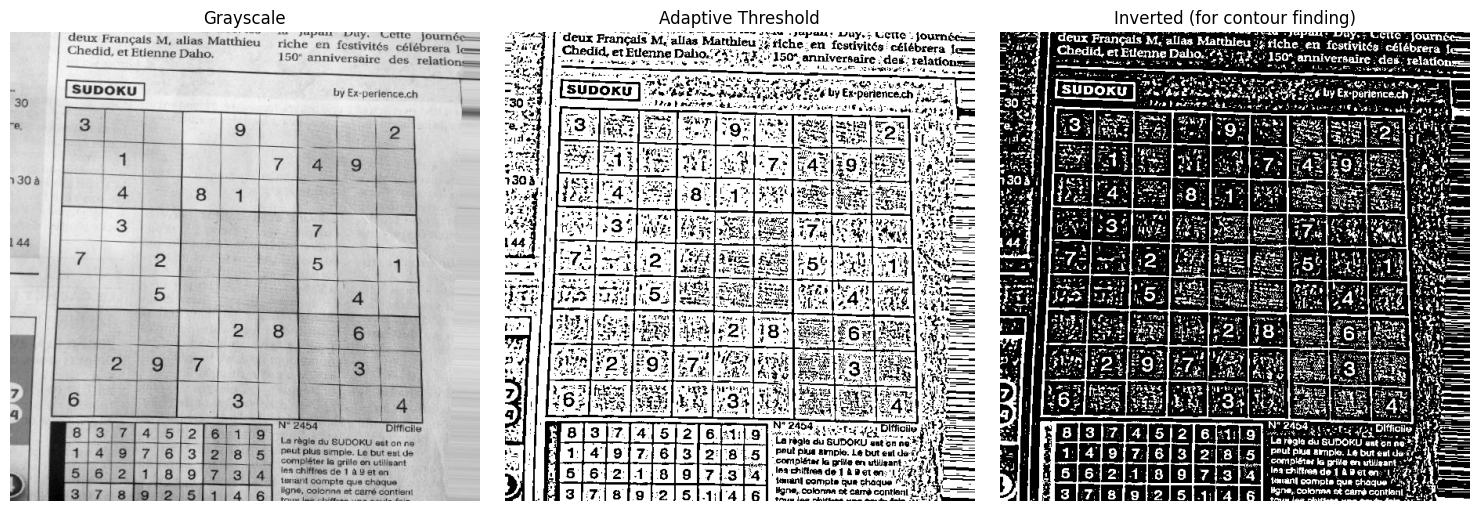

In [8]:
# Test on first image
test_img = images[0]
gray = cv2.cvtColor(test_img, cv2.COLOR_BGR2GRAY)

# Show thresholding
binary = adaptive_threshold(gray, block_size=11, c=2)
binary_inv = 255 - binary

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gray, cmap='gray')
axes[0].set_title('Grayscale')
axes[0].axis('off')

axes[1].imshow(binary, cmap='gray')
axes[1].set_title('Adaptive Threshold')
axes[1].axis('off')

axes[2].imshow(binary_inv, cmap='gray')
axes[2].set_title('Inverted (for contour finding)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Found 3324 contours


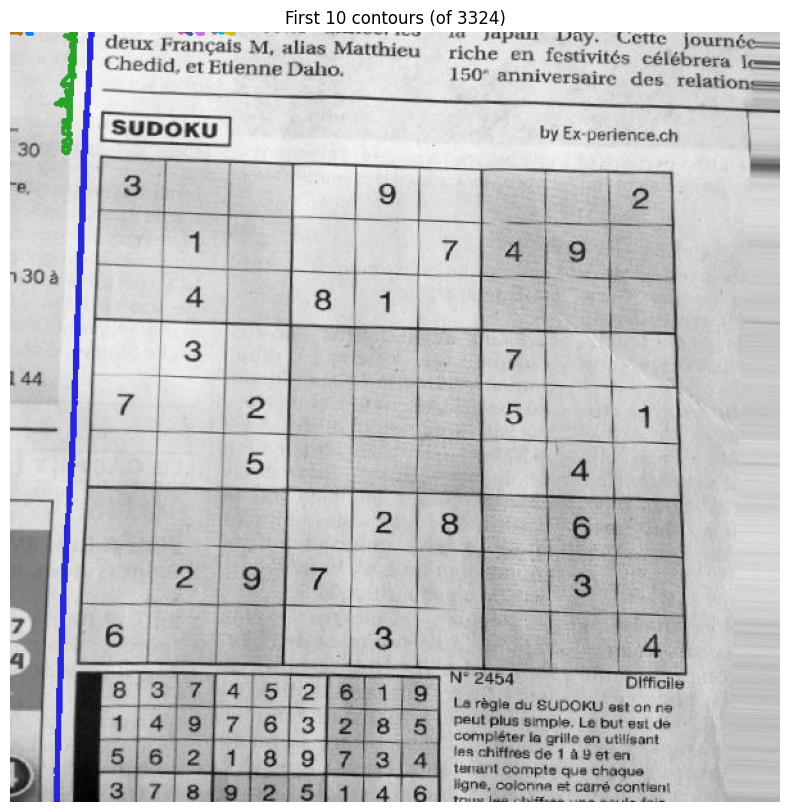

In [9]:
# Find and visualize contours
contours = find_contours(binary_inv)
print(f"Found {len(contours)} contours")

# Draw all contours
vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
for i, contour in enumerate(contours[:10]):  # Show first 10
    color = plt.cm.tab10(i % 10)[:3]
    color = tuple(int(c * 255) for c in color)
    for j in range(len(contour)):
        pt1 = tuple(contour[j][::-1])  # row,col -> x,y
        pt2 = tuple(contour[(j+1) % len(contour)][::-1])
        cv2.line(vis, pt1, pt2, color, 2)

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title(f'First 10 contours (of {len(contours)})')
plt.axis('off')
plt.show()

In [10]:
# Find Sudoku border
border = find_sudoku_border(test_img)

if border is not None:
    print("Found border!")
    print("Corners (row, col):")
    labels = ['TL', 'TR', 'BR', 'BL']
    for label, corner in zip(labels, border):
        print(f"  {label}: ({corner[0]:.0f}, {corner[1]:.0f})")
    
    # Visualize
    vis = test_img.copy()
    pts = border[:, ::-1].astype(np.int32)  # row,col -> x,y
    cv2.polylines(vis, [pts], True, (0, 255, 0), 3)
    
    for i, (label, pt) in enumerate(zip(labels, pts)):
        cv2.circle(vis, tuple(pt), 8, (0, 0, 255), -1)
        cv2.putText(vis, label, (pt[0] + 10, pt[1] + 10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title('Detected Sudoku Border')
    plt.axis('off')
    plt.show()
else:
    print("No border found!")

No border found!


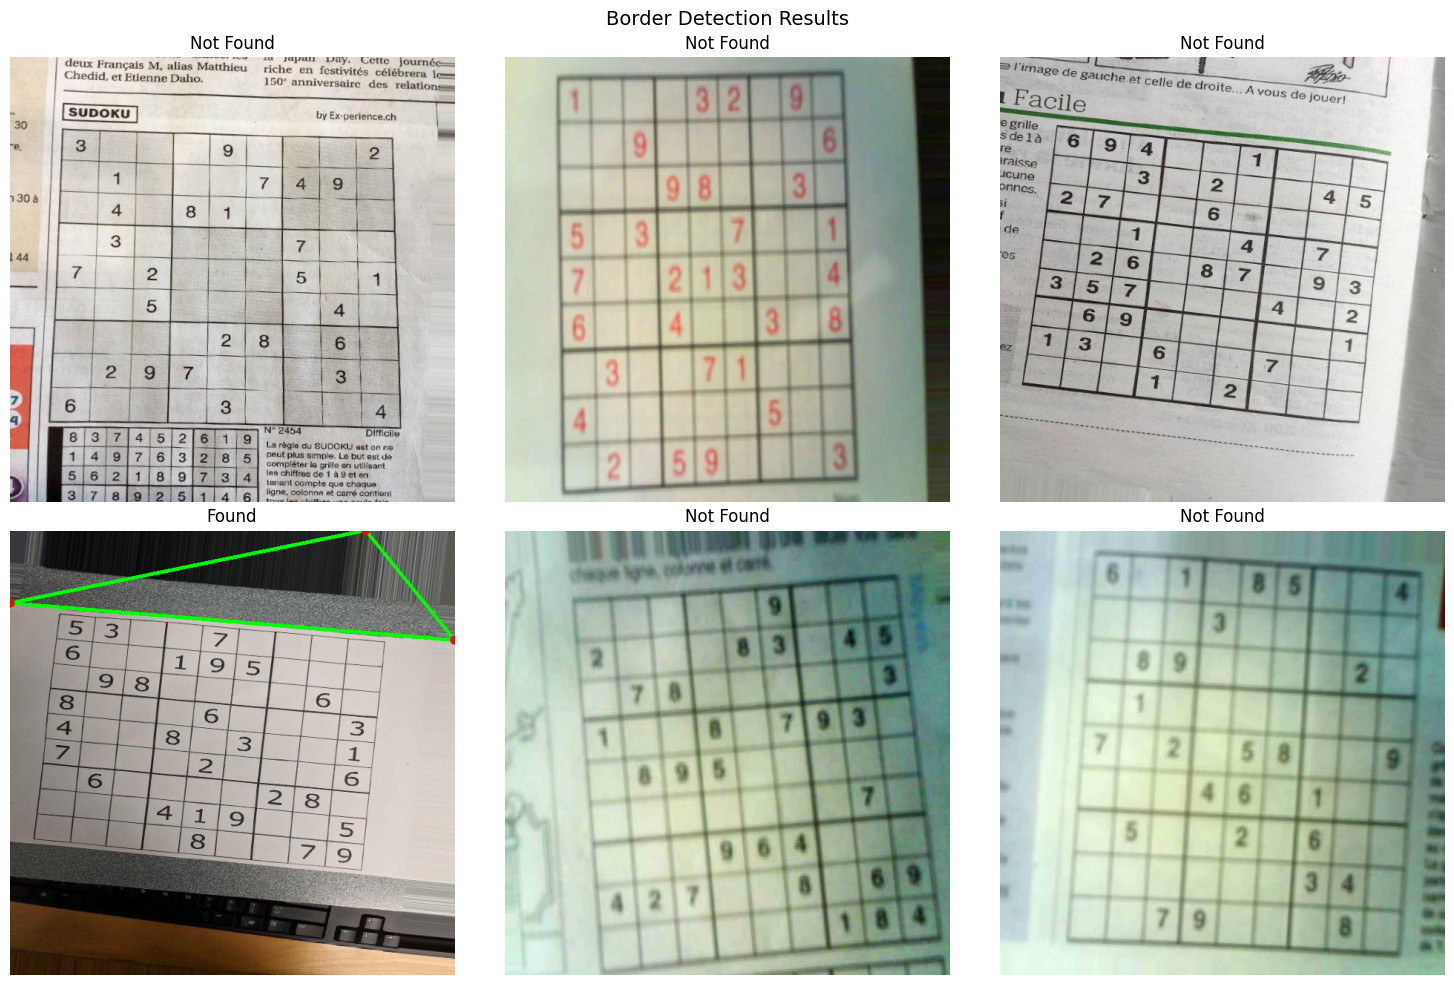

In [11]:
# Test on multiple images
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, img in zip(axes.flat, images):
    border = find_sudoku_border(img)
    
    vis = img.copy()
    if border is not None:
        pts = border[:, ::-1].astype(np.int32)
        cv2.polylines(vis, [pts], True, (0, 255, 0), 3)
        for pt in pts:
            cv2.circle(vis, tuple(pt), 6, (0, 0, 255), -1)
        title = 'Found'
    else:
        title = 'Not Found'
    
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')

plt.suptitle('Border Detection Results', fontsize=14)
plt.tight_layout()
plt.show()

---
## Summary

### What We Implemented

1. **Adaptive Thresholding** - Handle varying illumination
   - Uses integral image for O(1) per-pixel local mean
   - Threshold = local_mean - C

2. **Moore-Neighbor Contour Tracing** - Find boundaries
   - Walks around edge of connected regions
   - Uses 8-connectivity (Moore neighborhood)

3. **Douglas-Peucker** - Simplify polygons
   - Recursive algorithm
   - Removes points within ε of line between endpoints

4. **Corner Ordering** - Consistent quadrilateral representation
   - Uses sum/difference method
   - Output: [TL, TR, BR, BL]

### Key Formulas

| Operation | Formula |
|-----------|--------|
| Integral Image | $I'(x,y) = \sum_{i \le x, j \le y} I(i,j)$ |
| Rectangle Sum | $S = I'(x_2,y_2) - I'(x_1,y_2) - I'(x_2,y_1) + I'(x_1,y_1)$ |
| Perpendicular Dist | $d = \frac{|(P-A) \times (B-A)|}{|B-A|}$ |
| Shoelace Area | $A = \frac{1}{2}|\sum_i (x_i y_{i+1} - x_{i+1} y_i)|$ |

### What's Next?

In Notebook 03, we'll use the detected corners to:
1. Compute a homography matrix
2. Apply perspective transformation
3. Extract a square, standardized Sudoku grid